# Cork hourly weather data cleaning and visualisation (2021–2025)

This notebook cleans the uploaded hourly weather data for Roches Point / Cork and exports a model-ready CSV for the BEB weather-loading workflow.

**Main goals**

1. Load the raw Met Éireann-style CSV, which contains metadata rows before the real table.
2. Clean timestamps and numeric weather variables.
3. Check hourly completeness, duplicates, missing values, and basic physical ranges.
4. Create simple exploratory visualisations.
5. Export one clean CSV that can be used as input for the weather lookup / energy model.

**Important note on time**

The raw file states that the timestamp is in **UTC**. The exported `time` column is therefore kept as a unique hourly UTC timestamp. A separate `time_dublin_local` column is included for audit/reference, but the UTC `time` column is safer for model lookup because local Irish clock time has daylight-saving gaps and repeated hours.


## Step 0 — Imports and file paths

The path logic below works both in this ChatGPT sandbox and in a normal local folder. If you run this notebook locally, keep `hly1075_subset.csv` in the same folder as the notebook.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use /mnt/data in this environment; otherwise use the notebook folder.
RAW_DATA_DIR = Path('../data/raw/') if Path('../data/raw/hly1075_subset.csv').exists() else Path('.')
OUTPUT_DATA_DIR = Path('../data/processed/') if Path('../data/processed/').exists() else Path('.')
RAW_CSV = RAW_DATA_DIR / 'hly1075_subset.csv'
OUTPUT_CSV = OUTPUT_DATA_DIR / 'cork_weather_hourly_model_input_2021_2025.csv'

RAIN_THRESHOLD_MM = 0.1

print(f'Raw CSV:    {RAW_CSV}')
print(f'Output CSV: {OUTPUT_CSV}')

Raw CSV:    ..\data\raw\hly1075_subset.csv
Output CSV: ..\data\processed\cork_weather_hourly_model_input_2021_2025.csv


## Step 1 — Inspect the raw file structure

The raw file is not a standard CSV from the first row. It starts with station metadata and variable descriptions. We first locate the real table header, which starts with `date,ind,rain,...`.

In [2]:
with RAW_CSV.open('r', encoding='utf-8', errors='replace') as f:
    lines = f.readlines()

# Find the first line that looks like the actual CSV header.
header_row = next(i for i, line in enumerate(lines) if line.lower().startswith('date,'))

print(f'Header row index used by pandas skiprows: {header_row}')
print()
print('First 20 lines of the raw file:')
for i, line in enumerate(lines[:20], start=1):
    print(f'{i:02d}: {line.rstrip()}')

Header row index used by pandas skiprows: 17

First 20 lines of the raw file:
01: Station Name: ROCHES POINT
02: Station Height: 40 M
03: Latitude:51.793  ,Longitude: -8.244
04: 
05: 
06: date:  -  Date and Time (utc)
07: rain:  -  Precipitation Amount (mm)
08: temp:  -  Air Temperature (C)
09: wetb:  -  Wet Bulb Temperature (C)
10: dewpt: -  Dew Point Temperature (C)
11: vappr: -  Vapour Pressure (hPa)
12: rhum:  -  Relative Humidity (%)
13: msl:   -  Mean Sea Level Pressure (hPa)
14: wdsp:  -  Mean Wind Speed (kt)
15: wddir: -  Predominant Wind Direction (deg)
16: ind:   -  Indicator
17: 
18: date,ind,rain,ind,temp,ind,wetb,dewpt,vappr,rhum,msl,ind,wdsp,ind,wddir
19: 01-jan-2021 00:00,0,0.0,0,4.8,0,3.7,1.9,7.0,81,1013.5,2,17,2,340
20: 01-jan-2021 01:00,0,0.0,0,4.9,0,3.6,1.6,6.8,78,1013.5,2,18,2,340


## Step 2 — Load the raw weather table

The raw table contains repeated `ind` columns. These are indicator / quality flag columns. For the current model input, we keep the measured weather variables and drop the repeated indicator columns.

In [3]:
raw = pd.read_csv(RAW_CSV, skiprows=header_row)

print(f'Raw table shape: {raw.shape[0]:,} rows × {raw.shape[1]} columns')
print(raw.columns.tolist())
raw.head()

Raw table shape: 43,824 rows × 15 columns
['date', 'ind', 'rain', 'ind.1', 'temp', 'ind.2', 'wetb', 'dewpt', 'vappr', 'rhum', 'msl', 'ind.3', 'wdsp', 'ind.4', 'wddir']


,date,ind,rain,ind.1,temp,ind.2,wetb,dewpt,vappr,rhum,msl,ind.3,wdsp,ind.4,wddir
0,01-jan-2021 00:00,0,0.0,0,4.8,0,3.7,1.9,7.0,81,1013.5,2,17,2,340
1,01-jan-2021 01:00,0,0.0,0,4.9,0,3.6,1.6,6.8,78,1013.5,2,18,2,340
2,01-jan-2021 02:00,0,0.0,0,4.8,0,3.6,1.8,6.9,80,1014.1,2,18,2,350
3,01-jan-2021 03:00,0,0.0,0,4.7,0,3.5,1.7,6.9,80,1014.4,2,17,2,340
4,01-jan-2021 04:00,0,0.0,0,4.4,0,3.3,1.6,6.9,82,1014.9,2,16,2,340


## Step 3 — Parse timestamps and convert weather variables to numeric values

The weather loader needs a timestamp column and numeric weather variables. The key variables for the BEB weather-loading model are:

- `temp`: air temperature in °C
- `rhum`: relative humidity in %
- `rain`: precipitation in mm
- `solar`: solar radiation in W/m², not available in this Met Éireann file, so we add a placeholder value of `0.0`

Extra weather variables are kept because they may be useful later for exploratory analysis or future model features.

In [4]:
# Columns to keep from the raw file.
# The repeated indicator columns are excluded.
weather_cols = ['date', 'rain', 'temp', 'wetb', 'dewpt', 'vappr', 'rhum', 'msl', 'wdsp', 'wddir']
weather = raw[weather_cols].copy()

# Parse timestamp. The raw file uses values like '01-jan-2021 00:00'.
weather['time'] = pd.to_datetime(
    weather['date'].astype(str).str.strip(),
    format='%d-%b-%Y %H:%M',
    errors='coerce'
)

# Convert measured variables to numeric.
numeric_cols = ['rain', 'temp', 'wetb', 'dewpt', 'vappr', 'rhum', 'msl', 'wdsp', 'wddir']
for col in numeric_cols:
    weather[col] = pd.to_numeric(weather[col], errors='coerce')

# Put time first and sort chronologically.
weather = weather.drop(columns=['date']).sort_values('time')
weather = weather[['time'] + numeric_cols]

print(weather.dtypes)
weather.head()

time     datetime64[us]
rain            float64
temp            float64
wetb            float64
dewpt           float64
vappr           float64
rhum              int64
msl             float64
wdsp              int64
wddir             int64
dtype: object


,time,rain,temp,wetb,dewpt,vappr,rhum,msl,wdsp,wddir
0,2021-01-01 00:00:00,0.0,4.8,3.7,1.9,7.0,81,1013.5,17,340
1,2021-01-01 01:00:00,0.0,4.9,3.6,1.6,6.8,78,1013.5,18,340
2,2021-01-01 02:00:00,0.0,4.8,3.6,1.8,6.9,80,1014.1,18,350
3,2021-01-01 03:00:00,0.0,4.7,3.5,1.7,6.9,80,1014.4,17,340
4,2021-01-01 04:00:00,0.0,4.4,3.3,1.6,6.9,82,1014.9,16,340


## Step 4 — Data quality checks

This step checks whether the data is genuinely hourly from 2021 to 2025, and whether there are missing timestamps, duplicate timestamps, or missing values in key weather fields.

In [5]:
time_min = weather['time'].min()
time_max = weather['time'].max()
expected_time = pd.date_range(time_min, time_max, freq='h')
actual_time = pd.DatetimeIndex(weather['time'])
missing_time = expected_time.difference(actual_time)
duplicate_count = weather['time'].duplicated().sum()
missing_values = weather.isna().sum()

summary = pd.DataFrame({
    'metric': [
        'first_timestamp',
        'last_timestamp',
        'actual_rows',
        'expected_hourly_rows',
        'missing_hourly_timestamps',
        'duplicate_timestamps',
    ],
    'value': [
        time_min,
        time_max,
        len(weather),
        len(expected_time),
        len(missing_time),
        duplicate_count,
    ]
})

print(summary.to_string(index=False))
print()
print('Missing values by column:')
print(missing_values)

if len(missing_time) > 0:
    print()
    print('First missing timestamps:')
    print(missing_time[:20])

                   metric               value
          first_timestamp 2021-01-01 00:00:00
           last_timestamp 2025-12-31 23:00:00
              actual_rows               43824
     expected_hourly_rows               43824
missing_hourly_timestamps                   0
     duplicate_timestamps                   0

Missing values by column:
time     0
rain     0
temp     0
wetb     0
dewpt    0
vappr    0
rhum     0
msl      0
wdsp     0
wddir    0
dtype: int64


## Step 5 — Reindex to a complete hourly timeline

Even if no missing timestamps are found, this step makes the notebook robust. It creates a complete hourly index from the first timestamp to the last timestamp. If missing values exist in another version of the file, continuous variables are interpolated and missing rainfall is set to `0.0` only for missing rows.

In [6]:
# Remove duplicate timestamps if they ever exist, then reindex to a complete hourly timeline.
clean = (
    weather
    .drop_duplicates(subset='time', keep='last')
    .set_index('time')
    .reindex(expected_time)
)
clean.index.name = 'time'

# Keep a flag before filling, so we can audit whether a row was originally missing.
clean['was_missing_timestamp'] = clean[numeric_cols].isna().all(axis=1).astype(int)

# Fill only if needed.
continuous_cols = ['temp', 'wetb', 'dewpt', 'vappr', 'rhum', 'msl', 'wdsp']
if clean[numeric_cols].isna().any().any():
    clean[continuous_cols] = clean[continuous_cols].interpolate(method='time', limit_direction='both')
    clean['rain'] = clean['rain'].fillna(0.0)
    clean['wddir'] = clean['wddir'].ffill().bfill()

print(f'Clean hourly rows: {len(clean):,}')
print(f'Rows created by reindexing: {clean["was_missing_timestamp"].sum():,}')
print()
print('Remaining missing values:')
print(clean.isna().sum())

clean.head()

Clean hourly rows: 43,824
Rows created by reindexing: 0

Remaining missing values:
rain                     0
temp                     0
wetb                     0
dewpt                    0
vappr                    0
rhum                     0
msl                      0
wdsp                     0
wddir                    0
was_missing_timestamp    0
dtype: int64


,rain,temp,wetb,dewpt,vappr,rhum,msl,wdsp,wddir,was_missing_timestamp
time,,,,,,,,,,
2021-01-01 00:00:00,0.0,4.8,3.7,1.9,7.0,81,1013.5,17,340,0
2021-01-01 01:00:00,0.0,4.9,3.6,1.6,6.8,78,1013.5,18,340,0
2021-01-01 02:00:00,0.0,4.8,3.6,1.8,6.9,80,1014.1,18,350,0
2021-01-01 03:00:00,0.0,4.7,3.5,1.7,6.9,80,1014.4,17,340,0
2021-01-01 04:00:00,0.0,4.4,3.3,1.6,6.9,82,1014.9,16,340,0


## Step 6 — Basic physical range checks

These are simple sanity checks, not strict meteorological validation. They help catch obvious parsing errors before the CSV is used by the energy model.

In [7]:
range_checks = {
    'temp_below_-20_or_above_40': ((clean['temp'] < -20) | (clean['temp'] > 40)).sum(),
    'rhum_outside_0_100': ((clean['rhum'] < 0) | (clean['rhum'] > 100)).sum(),
    'negative_rain': (clean['rain'] < 0).sum(),
    'negative_wind_speed': (clean['wdsp'] < 0).sum(),
    'wddir_outside_0_360': ((clean['wddir'] < 0) | (clean['wddir'] > 360)).sum(),
}

pd.Series(range_checks, name='count').to_frame()

,count
temp_below_-20_or_above_40,0
rhum_outside_0_100,0
negative_rain,0
negative_wind_speed,0
wddir_outside_0_360,0


In [8]:
# Descriptive statistics for the main measured variables.
clean[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
rain,43824.0,0.125415,0.524479,0.0,0.0,0.0,0.0,10.7
temp,43824.0,11.353270,4.036799,-3.5,8.8,11.3,14.3,26.1
wetb,43824.0,10.059748,3.875420,-3.6,7.5,10.2,12.9,20.4
dewpt,43824.0,8.682745,4.294629,-6.4,5.8,9.1,11.8,18.7
vappr,43824.0,11.648380,3.252092,3.8,9.2,11.5,13.8,21.5
rhum,43824.0,83.873631,10.713447,34.0,77.0,85.0,92.0,100.0
msl,43824.0,1014.017064,12.388269,961.1,1006.6,1015.4,1022.8,1046.8
wdsp,43824.0,12.199548,6.388191,1.0,8.0,11.0,16.0,55.0
wddir,43824.0,215.766703,89.729865,10.0,160.0,220.0,300.0,360.0


## Step 7 — Add model-friendly fields

The uploaded loader can auto-detect columns such as `time`, `temp`, `rhum`, `rain`, and `solar`. This dataset does not contain solar radiation, so `solar = 0.0` is added as an explicit placeholder. If a solar radiation dataset is added later, replace this placeholder with measured or estimated shortwave radiation in W/m².

`is_raining` uses the same rainfall threshold idea as the weather loader: rainfall above `0.1 mm` is treated as raining.

In [9]:
model = clean.copy()

# Explicit placeholder because the source file does not include solar radiation.
model['solar'] = 0.0
model['is_raining'] = (model['rain'] > RAIN_THRESHOLD_MM).astype(int)

# Calendar features may help later for diagnostics or model grouping.
model['year'] = model.index.year
model['month'] = model.index.month
model['day'] = model.index.day
model['hour'] = model.index.hour
model['dayofweek'] = model.index.dayofweek

# Add UTC and Dublin local clock reference columns.
# Keep `time` as the primary UTC timestamp for uniqueness.
time_utc = pd.DatetimeIndex(model.index).tz_localize('UTC')
time_dublin = time_utc.tz_convert('Europe/Dublin')

out = model.copy()
out.insert(0, 'time', model.index.strftime('%Y-%m-%d %H:%M:%S'))
out.insert(1, 'time_utc', model.index.strftime('%Y-%m-%d %H:%M:%S'))
out.insert(2, 'time_dublin_local', time_dublin.strftime('%Y-%m-%d %H:%M:%S%z'))

# Final column order: model-critical columns first, extra variables after.
final_cols = [
    'time', 'time_utc', 'time_dublin_local',
    'year', 'month', 'day', 'hour', 'dayofweek',
    'temp', 'rhum', 'rain', 'solar', 'is_raining',
    'wetb', 'dewpt', 'vappr', 'msl', 'wdsp', 'wddir',
    'was_missing_timestamp'
]
out = out[final_cols]

out.head()

,time,time_utc,time_dublin_local,year,month,day,hour,dayofweek,temp,rhum,rain,solar,is_raining,wetb,dewpt,vappr,msl,wdsp,wddir,was_missing_timestamp
time,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,2021-01-01 00:00:00,2021-01-01 00:00:00,2021-01-01 00:00:00+0000,2021,1,1,0,4,4.8,81,0.0,0.0,0,3.7,1.9,7.0,1013.5,17,340,0
2021-01-01 01:00:00,2021-01-01 01:00:00,2021-01-01 01:00:00,2021-01-01 01:00:00+0000,2021,1,1,1,4,4.9,78,0.0,0.0,0,3.6,1.6,6.8,1013.5,18,340,0
2021-01-01 02:00:00,2021-01-01 02:00:00,2021-01-01 02:00:00,2021-01-01 02:00:00+0000,2021,1,1,2,4,4.8,80,0.0,0.0,0,3.6,1.8,6.9,1014.1,18,350,0
2021-01-01 03:00:00,2021-01-01 03:00:00,2021-01-01 03:00:00,2021-01-01 03:00:00+0000,2021,1,1,3,4,4.7,80,0.0,0.0,0,3.5,1.7,6.9,1014.4,17,340,0
2021-01-01 04:00:00,2021-01-01 04:00:00,2021-01-01 04:00:00,2021-01-01 04:00:00+0000,2021,1,1,4,4,4.4,82,0.0,0.0,0,3.3,1.6,6.9,1014.9,16,340,0


## Step 8 — Visualisation 1: daily mean temperature

This shows the broad seasonal temperature pattern from 2021 to 2025. The 30-day rolling mean smooths short-term weather noise.

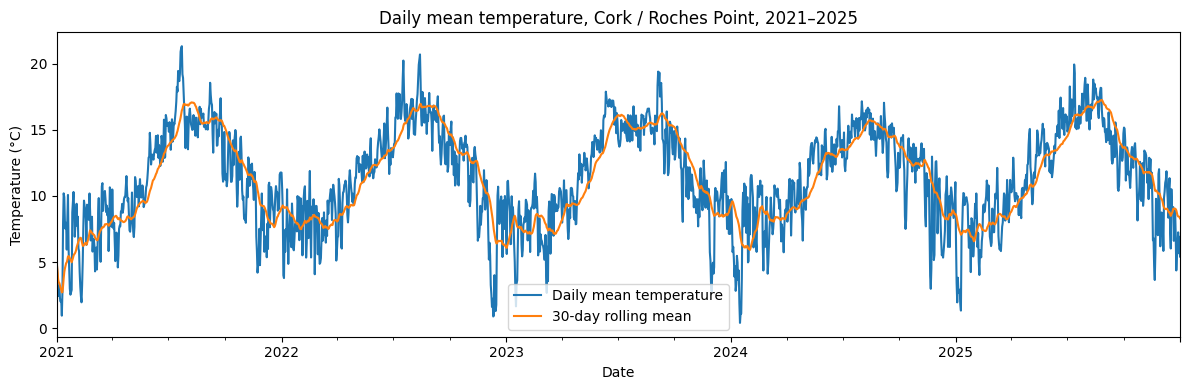

In [10]:
daily_temp = clean['temp'].resample('D').mean()

plt.figure(figsize=(12, 4))
daily_temp.plot(label='Daily mean temperature')
daily_temp.rolling(30, min_periods=1).mean().plot(label='30-day rolling mean')
plt.title('Daily mean temperature, Cork / Roches Point, 2021–2025')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 9 — Visualisation 2: monthly temperature distribution

This boxplot summarises the distribution of hourly air temperature by month across all five years.

C:\Users\ninglin.ou\AppData\Local\Temp\ipykernel_25220\3021418924.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=month_labels, showfliers=False)


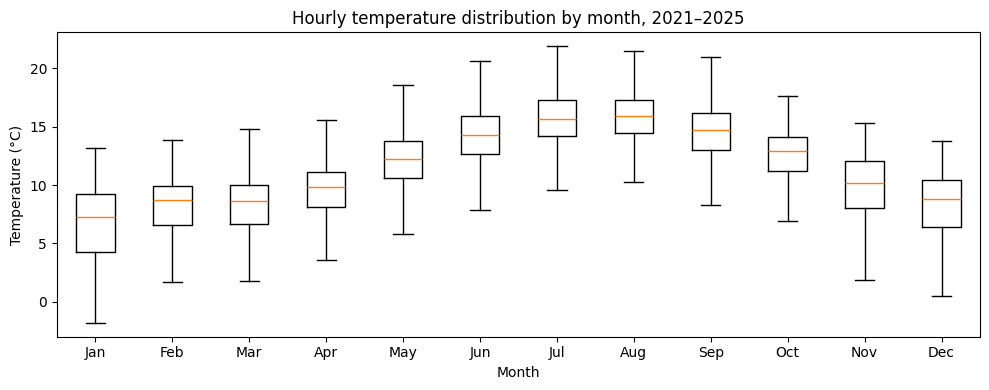

In [11]:
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
box_data = [clean.loc[clean.index.month == month, 'temp'].dropna() for month in range(1, 13)]

plt.figure(figsize=(10, 4))
plt.boxplot(box_data, labels=month_labels, showfliers=False)
plt.title('Hourly temperature distribution by month, 2021–2025')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

## Step 10 — Visualisation 3: average monthly rainfall total

This plot aggregates rainfall by year and month, then shows the average monthly total across 2021–2025.

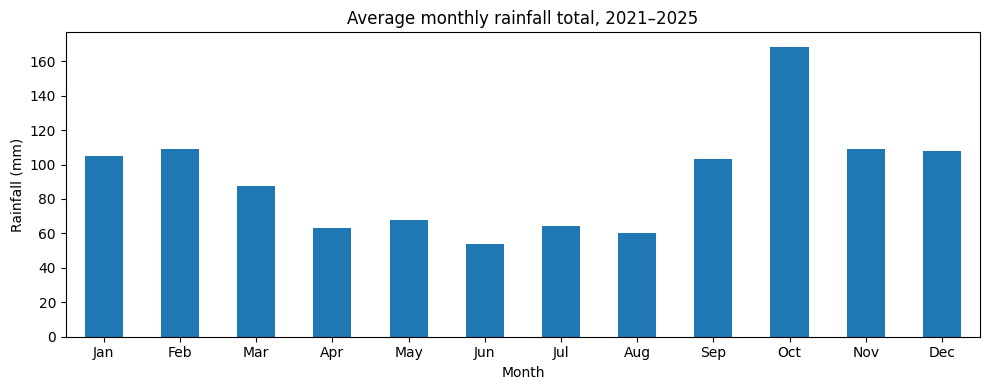

In [12]:
monthly_rain_by_year = clean['rain'].groupby([clean.index.year, clean.index.month]).sum()
avg_monthly_rain = monthly_rain_by_year.groupby(level=1).mean()

plt.figure(figsize=(10, 4))
avg_monthly_rain.plot(kind='bar')
plt.title('Average monthly rainfall total, 2021–2025')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.xticks(ticks=range(12), labels=month_labels, rotation=0)
plt.tight_layout()
plt.show()

## Step 11 — Visualisation 4: mean temperature by month and hour

This heatmap checks whether the diurnal temperature pattern looks reasonable. It uses month on the x-axis and hour of day on the y-axis.

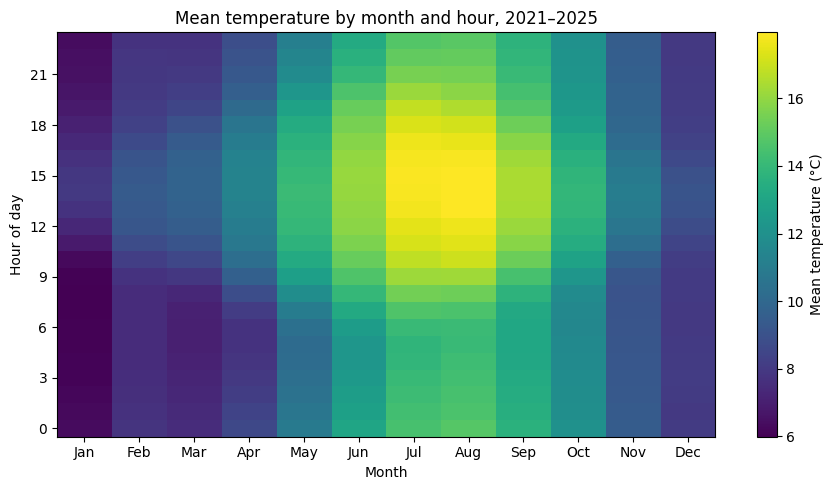

In [13]:
heat = clean.pivot_table(
    values='temp',
    index=clean.index.hour,
    columns=clean.index.month,
    aggfunc='mean'
)

plt.figure(figsize=(9, 5))
plt.imshow(heat, aspect='auto', origin='lower')
plt.colorbar(label='Mean temperature (°C)')
plt.title('Mean temperature by month and hour, 2021–2025')
plt.xlabel('Month')
plt.ylabel('Hour of day')
plt.xticks(ticks=np.arange(12), labels=month_labels)
plt.yticks(ticks=np.arange(0, 24, 3))
plt.tight_layout()
plt.show()

## Step 12 — Export the cleaned model input CSV

The exported CSV is designed to be easy for the weather loader to read. The most important columns are:

- `time`: UTC timestamp, unique and hourly
- `temp`: air temperature in °C
- `rhum`: relative humidity in %
- `rain`: precipitation in mm
- `solar`: placeholder solar radiation in W/m²

The additional columns are kept for checking and future feature engineering.

In [14]:
out.to_csv(OUTPUT_CSV, index=False)

print(f'Saved: {OUTPUT_CSV}')
print(f'Rows: {len(out):,}')
print(f'Columns: {len(out.columns)}')
print()
print('Output preview:')
out.head()

Saved: ..\data\processed\cork_weather_hourly_model_input_2021_2025.csv
Rows: 43,824
Columns: 20

Output preview:


,time,time_utc,time_dublin_local,year,month,day,hour,dayofweek,temp,rhum,rain,solar,is_raining,wetb,dewpt,vappr,msl,wdsp,wddir,was_missing_timestamp
time,,,,,,,,,,,,,,,,,,,,
2021-01-01 00:00:00,2021-01-01 00:00:00,2021-01-01 00:00:00,2021-01-01 00:00:00+0000,2021,1,1,0,4,4.8,81,0.0,0.0,0,3.7,1.9,7.0,1013.5,17,340,0
2021-01-01 01:00:00,2021-01-01 01:00:00,2021-01-01 01:00:00,2021-01-01 01:00:00+0000,2021,1,1,1,4,4.9,78,0.0,0.0,0,3.6,1.6,6.8,1013.5,18,340,0
2021-01-01 02:00:00,2021-01-01 02:00:00,2021-01-01 02:00:00,2021-01-01 02:00:00+0000,2021,1,1,2,4,4.8,80,0.0,0.0,0,3.6,1.8,6.9,1014.1,18,350,0
2021-01-01 03:00:00,2021-01-01 03:00:00,2021-01-01 03:00:00,2021-01-01 03:00:00+0000,2021,1,1,3,4,4.7,80,0.0,0.0,0,3.5,1.7,6.9,1014.4,17,340,0
2021-01-01 04:00:00,2021-01-01 04:00:00,2021-01-01 04:00:00,2021-01-01 04:00:00+0000,2021,1,1,4,4,4.4,82,0.0,0.0,0,3.3,1.6,6.9,1014.9,16,340,0


In [ ]:
# Keep only the columns required by the next modelling step
output_columns = ['time', 'year', 'month', 'day', 'temp', 'rhum', 'solar']
out = out[output_columns].copy()

out.to_csv(OUTPUT_CSV, index=False)

print(f'Saved: {OUTPUT_CSV}')
print(f'Rows: {len(out):,}')
print(f'Columns: {len(out.columns)}')
print()
print('Output preview:')
out.head()

Saved: ..\data\processed\cork_weather_hourly_model_input_2021_2025.csv
Rows: 43,824
Columns: 6

Output preview:


,time,year,month,day,temp,rhum
time,,,,,,
2021-01-01 00:00:00,2021-01-01 00:00:00,2021,1,1,4.8,81
2021-01-01 01:00:00,2021-01-01 01:00:00,2021,1,1,4.9,78
2021-01-01 02:00:00,2021-01-01 02:00:00,2021,1,1,4.8,80
2021-01-01 03:00:00,2021-01-01 03:00:00,2021,1,1,4.7,80
2021-01-01 04:00:00,2021-01-01 04:00:00,2021,1,1,4.4,82


## Step 13 — Optional loader check

If your weather lookup module is saved as `weather_series.py` and your physics module is saved separately as `weather_loading.py`, you can test the output with the cell below.

The uploaded script is logically named `weather_series.py` in its own header, but the uploaded file name is `weather_loading.py`. If both the data-source loader and the physics module have the same file name, Python may import the wrong file. Keep the data-source loader and the physics module as separate files.

In [16]:
# Optional test after placing the cleaned CSV beside your project files:
#
# from weather_series import load_temperature_csv
# series = load_temperature_csv(
#     OUTPUT_CSV,
#     time_col='time',
#     temp_col='temp',
#     rh_col='rhum',
#     solar_col='solar',
#     rain_col='rain',
#     verbose=True,
# )
# cold, median, hot = series.design_days()
# print(cold, median, hot)

In [17]:
# Prepare humidity data for visualisation only
humidity_df = out.copy()

humidity_df['time'] = pd.to_datetime(humidity_df['time'])
humidity_df['year'] = humidity_df['time'].dt.year
humidity_df['month'] = humidity_df['time'].dt.month
humidity_df['hour'] = humidity_df['time'].dt.hour
humidity_df['date'] = humidity_df['time'].dt.date

# Make sure relative humidity is in percentage scale
# If rhum is stored as 0-1, convert to 0-100
if humidity_df['rhum'].max() <= 1.5:
    humidity_df['rhum_pct'] = humidity_df['rhum'] * 100
else:
    humidity_df['rhum_pct'] = humidity_df['rhum']

humidity_df[['time', 'year', 'month', 'hour', 'temp', 'rhum_pct']].head()

,time,year,month,hour,temp,rhum_pct
time,,,,,,
2021-01-01 00:00:00,2021-01-01 00:00:00,2021,1,0,4.8,81
2021-01-01 01:00:00,2021-01-01 01:00:00,2021,1,1,4.9,78
2021-01-01 02:00:00,2021-01-01 02:00:00,2021,1,2,4.8,80
2021-01-01 03:00:00,2021-01-01 03:00:00,2021,1,3,4.7,80
2021-01-01 04:00:00,2021-01-01 04:00:00,2021,1,4,4.4,82


In [18]:
humidity_summary = humidity_df['rhum_pct'].describe()

print('Relative humidity summary (%)')
print(humidity_summary.round(2))

Relative humidity summary (%)
count    43824.00
mean        83.87
std         10.71
min         34.00
25%         77.00
50%         85.00
75%         92.00
max        100.00
Name: rhum_pct, dtype: float64


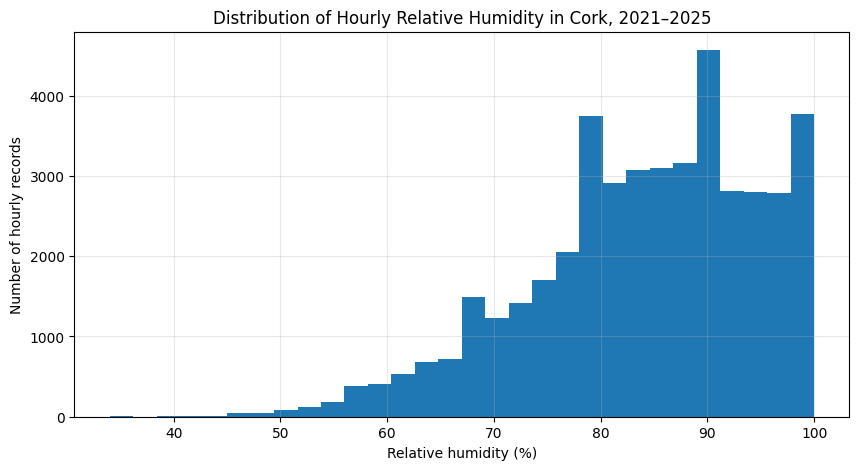

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(humidity_df['rhum_pct'].dropna(), bins=30)

plt.title('Distribution of Hourly Relative Humidity in Cork, 2021–2025')
plt.xlabel('Relative humidity (%)')
plt.ylabel('Number of hourly records')
plt.grid(True, alpha=0.3)

plt.show()

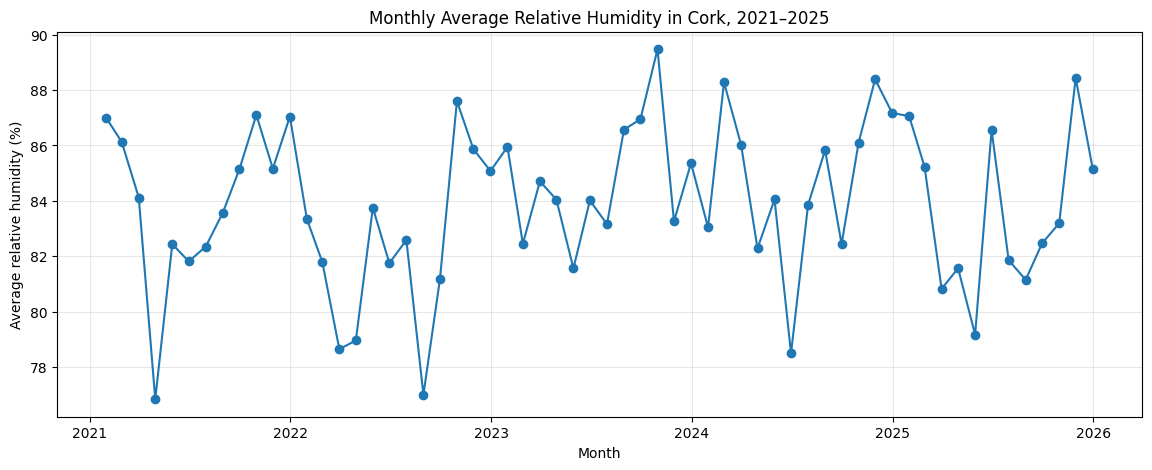

In [21]:
monthly_humidity = (
    humidity_df
    .set_index('time')
    .resample('ME')['rhum_pct']
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(monthly_humidity.index, monthly_humidity.values, marker='o', linewidth=1.5)

plt.title('Monthly Average Relative Humidity in Cork, 2021–2025')
plt.xlabel('Month')
plt.ylabel('Average relative humidity (%)')
plt.grid(True, alpha=0.3)

plt.show()

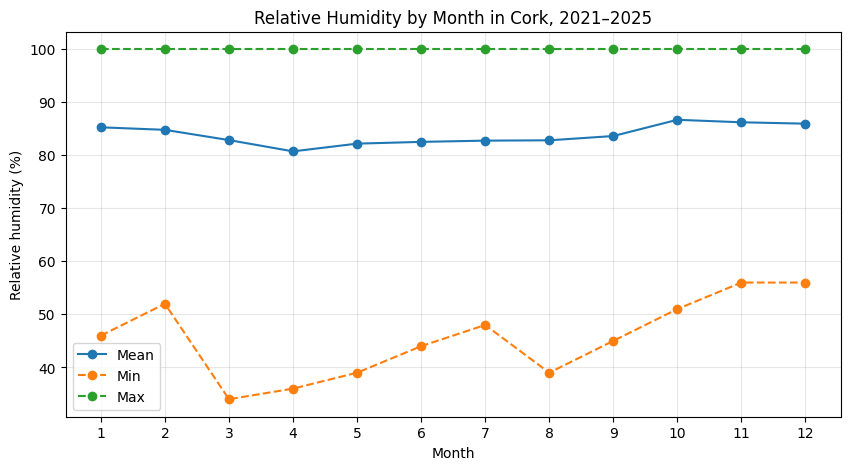

In [22]:
monthly_pattern = (
    humidity_df
    .groupby('month')['rhum_pct']
    .agg(['mean', 'min', 'max'])
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(monthly_pattern['month'], monthly_pattern['mean'], marker='o', label='Mean')
plt.plot(monthly_pattern['month'], monthly_pattern['min'], marker='o', linestyle='--', label='Min')
plt.plot(monthly_pattern['month'], monthly_pattern['max'], marker='o', linestyle='--', label='Max')

plt.title('Relative Humidity by Month in Cork, 2021–2025')
plt.xlabel('Month')
plt.ylabel('Relative humidity (%)')
plt.xticks(range(1, 13))
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

<Figure size 1200x500 with 0 Axes>

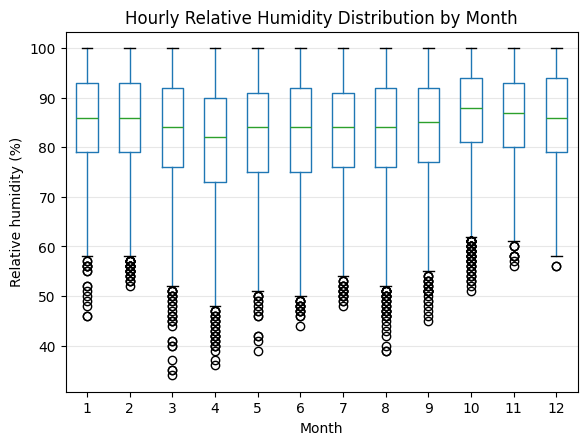

In [23]:
plt.figure(figsize=(12, 5))

humidity_df.boxplot(
    column='rhum_pct',
    by='month',
    grid=False
)

plt.title('Hourly Relative Humidity Distribution by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Relative humidity (%)')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

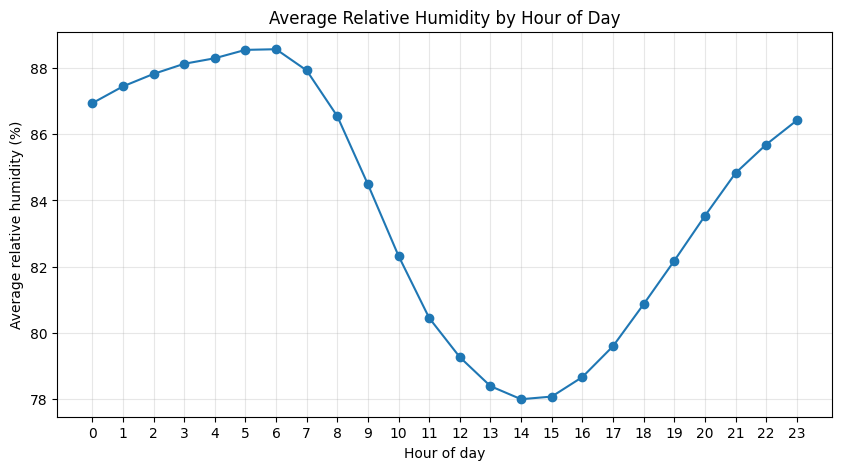

In [24]:
hourly_humidity = (
    humidity_df
    .groupby('hour')['rhum_pct']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(hourly_humidity['hour'], hourly_humidity['rhum_pct'], marker='o')

plt.title('Average Relative Humidity by Hour of Day')
plt.xlabel('Hour of day')
plt.ylabel('Average relative humidity (%)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)

plt.show()